In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
import os
import pathlib
import glob

In [2]:
os.getenv('CENSUS_API_KEY')

In [3]:
HOME_DIR = pathlib.Path.home()
# in my (AO) case, M:\urban_modeling is mounted to /Volumes/Data/Models/urban_modeling
m_path = M_DRIVE = pathlib.Path(
    "/Volumes/Data/Models") if os.name != "nt" else pathlib.Path("M:/")

box_path = HOME_DIR / 'Library/CloudStorage/Box-Box'
m_path

WindowsPath('M:/')

In [4]:
ca_fips_path = m_path / 'Crosswalks/geo/st06_ca_cou2020.txt'
ca_fips = pd.read_csv(ca_fips_path, sep='|', dtype=str)
ca_fips['STCOUNTY'] = ca_fips.STATEFP+ca_fips.COUNTYFP
ca_fips['county_name'] = ca_fips.COUNTYNAME.str.replace(
    ' County', '').str.strip()
ca_fips = ca_fips.set_index('STCOUNTY').county_name

In [5]:
bayareafips_full ={'06001':'Alameda', '06013':'Contra Costa', '06041':'Marin', '06055':'Napa', '06075':'San Francisco', '06081':'San Mateo', '06085':'Santa Clara', '06097':'Sonoma', '06095':'Solano'}


# Mappings and correspondences

In [6]:
def geoprocessor(df, puma_to_county):

    df['STPUMA'] = df.apply(
        lambda x: f'{x.ST:02d}{x.PUMA:05d}', axis=1)

    df['county_name'] = df['STPUMA'].map(
        puma_to_county).str.replace(' County (CA)', '', regex=False)
    
    hh_bayarea_19_mask = df.county_name.isin(ca_fips.values())

    hh_bayarea_19 = df.loc[hh_bayarea_19_mask]
    return hh_bayarea_19

In [7]:
pct = lambda x: x/x.sum()

In [8]:
# state abbreviations

state_abbrev = pd.read_csv('https://www2.census.gov/geo/docs/reference/state.txt',sep='|',dtype=str)

In [9]:
def format_labels(cut_bins, format_strings):
    labels = [*(f'{a+1}-{b}' for a, b in zip(cut_bins[:-1], cut_bins[1:]))]
    labels[0] = format_strings[0] % cut_bins[1]
    labels[-1] = format_strings[-1] % cut_bins[-2]
    return labels

age_bins = range(0,86,10)
format_strings = ['< %s', '%s-%s',  '> %s']
age_labels = format_labels(age_bins, format_strings)
age_labels

['< 10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '> 70']

# Load PUMS data

In [10]:
hh_ca_23_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2023/csv_hca/psam_h06.csv'
hh_ca_21_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2021/csv_hca/psam_h06.csv'
hh_ca_15_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2015/ss151yrhca.csv'
hh_ca_19_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2019/csv_hca/psam_h06.csv'
hh_ca_10_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2010/ss101yrhca.csv'

In [11]:
pers_ca_13_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2013/psam_p06.csv'
pers_ca_15_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2015/ss151yrpca.csv'
pers_ca_17_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2017/csv_pca/psam_p06.csv'
pers_ca_18_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2018/csv_pca/psam_p06.csv'
pers_ca_19_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2019/csv_pca/psam_p06.csv'
pers_ca_21_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2021/csv_pca/psam_p06.csv'
pers_ca_23_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2023/csv_pca/psam_p06.csv'


In [12]:
data_base_path = pathlib.Path(r'C:\Users\aolsen\Downloads')
data_base_path = M_DRIVE / 'Data/Census/PUMS'
data_base_path

WindowsPath('M:/Data/Census/PUMS')

In [15]:
import pandas as pd
import pathlib
import re

# dictionary of known column aliases across vintages
COLUMN_ALIASES = {
    "STATE": ["ST", "STATE"],
    "PUMA": ["PUMA", "PUMA00", "PUMA10"],
    "SERIALNO": ["SERIALNO"],
    "AGEP": ["AGEP", "AGE"],  # name varies
}


def resolve_columns(file_path, keep_cols, verbose=True):
    """Resolve which actual columns to load from a file header."""
    header = pd.read_csv(file_path, nrows=0)
    available = [c for c in header.columns]  # preserve case
    # map normalized→actual
    available_upper = {c.upper(): c for c in available}

    col_map = {}

    for c in keep_cols:
        uc = c.upper()

        # Replicate weights special case
        if uc.startswith("PWGTP") and uc[5:].isdigit():
            # determine if uppercase or lowercase pattern is present
            sample_name = f"PWGTP1"
            sample_name_lower = sample_name.lower()
            if sample_name in available:
                # uppercase style
                prefix = "PWGTP"
            elif sample_name_lower in available:
                # lowercase style
                prefix = "pwgtp"
            else:
                if verbose:
                    print(
                        f"    Warning: replicate weights not found in {file_path.name}")
                continue

            # figure out how many replicate weights exist in the file
            for col in available:
                m = re.match(rf"^{prefix}(\d+)$", col)
                if m:
                    idx = int(m.group(1))
                    if 1 <= idx <= 80:  # safe range
                        col_map[f"PWGTP{idx}"] = col
            continue

        # Standard aliases
        if uc in available_upper:
            col_map[c] = available_upper[uc]
        elif uc in COLUMN_ALIASES:
            found = next(
                (v for v in COLUMN_ALIASES[uc] if v in available_upper), None)
            if found:
                col_map[c] = available_upper[found]

    return col_map


def load_pums_year(base_path, year, keep_cols, verbose=True):
    base = pathlib.Path(base_path)
    year_path = base / f"PUMS {year}"
    if verbose:
        print(f"\n--- Loading PUMS {year} ---")

    patterns = ["psam_pus*.csv", f"ss{str(year)[-2:]}pus*.csv"]

    files = []
    for pat in patterns:
        files.extend(sorted(year_path.glob(pat)))

    if not files:
        raise FileNotFoundError(f"No PUMS CSVs found under {year_path}")

    dfs = []
    for f in files:
        if verbose:
            print(f"  → Resolving columns in {f.name}")
        col_map = resolve_columns(f, keep_cols, verbose=verbose)
        if verbose:
            print(
                f"    Column mapping resolved: {list(col_map.items())[:10]}{' ...' if len(col_map) > 10 else ''}")

        if not col_map:
            raise ValueError(f"No requested columns found in {f.name}")

        df = pd.read_csv(f, usecols=list(col_map.values()))
        df = df.rename(columns={v: k for k, v in col_map.items()})
        df["year"] = year
        dfs.append(df)
        if verbose:
            print(f"    Loaded shape {df.shape}")

    out = pd.concat(dfs, ignore_index=True)
    if verbose:
        print(f"Finished PUMS {year}. Final shape: {out.shape}")
    return out


def load_pums_multi(base_path, years, keep_cols, verbose=True):
    all_dfs = []
    if verbose:
        print(f"=== Starting multi-year load: {years} ===")
    for y in years:
        df_year = load_pums_year(base_path, y, keep_cols, verbose=verbose)
        all_dfs.append(df_year)
    out = pd.concat(all_dfs, ignore_index=True)
    if verbose:
        print(f"=== Finished multi-year load. Combined shape: {out.shape} ===")
    return out


years = [2013, 2015,2017,2019,2021,2023]  
years = [2013, 2023, 2024]   
#keep_cols = ["STATE", "PUMA", "SERIALNO", "SPORDER", "AGEP","PWGTP","MAR","SEX","MARHM","MARHT"]
keep_cols =  ["STATE", "PUMA", "AGEP","PWGTP","MAR","SEX","MARHM","MARHT","SCHG"] + [f"PWGTP{i}" for i in range(1,81)]

#['SERIALNO','PWGTP','MAR','PUMA','ST','AGEP'

df = load_pums_multi(data_base_path, years, keep_cols)

print(df.head())

=== Starting multi-year load: [2013, 2023, 2024] ===

--- Loading PUMS 2013 ---
  → Resolving columns in psam_pusa.csv
    Column mapping resolved: [('STATE', 'ST'), ('PUMA', 'PUMA'), ('AGEP', 'AGEP'), ('PWGTP', 'PWGTP'), ('MAR', 'MAR'), ('SEX', 'SEX'), ('MARHM', 'MARHM'), ('MARHT', 'MARHT'), ('SCHG', 'SCHG'), ('PWGTP1', 'PWGTP1')] ...
    Loaded shape (1648512, 90)
  → Resolving columns in psam_pusb.csv
    Column mapping resolved: [('STATE', 'ST'), ('PUMA', 'PUMA'), ('AGEP', 'AGEP'), ('PWGTP', 'PWGTP'), ('MAR', 'MAR'), ('SEX', 'SEX'), ('MARHM', 'MARHM'), ('MARHT', 'MARHT'), ('SCHG', 'SCHG'), ('PWGTP1', 'PWGTP1')] ...
    Loaded shape (1566027, 90)
Finished PUMS 2013. Final shape: (3214539, 90)

--- Loading PUMS 2023 ---
  → Resolving columns in psam_pusa.csv
    Column mapping resolved: [('STATE', 'STATE'), ('PUMA', 'PUMA'), ('AGEP', 'AGEP'), ('PWGTP', 'PWGTP'), ('MAR', 'MAR'), ('SEX', 'SEX'), ('MARHM', 'MARHM'), ('MARHT', 'MARHT'), ('SCHG', 'SCHG'), ('PWGTP1', 'PWGTP1')] ...
    Loa

In [16]:
pers_ca = df
#pers_ca['year']=pers_ca.YEAR

In [17]:
# THESE WERE FROM AN EARLIER MANUAL APPROACH - COMMENTING OUT

# pers_ca_18 = pd.read_csv(pers_ca_18_path)#,usecols=pers_cols)

# pers_ca_13_path = '/Users/aolsen/Dropbox/Documents/Data/_Census/ACS/PUMS/2013/psam_p06.csv'

# pers_cols = ['SERIALNO','PWGTP','MAR','PUMA','ST','AGEP']
# pers_cols_23 = ['SERIALNO','PWGTP','MAR','PUMA','STATE','AGEP']

# pers_ca_13 = pd.read_csv(pers_ca_13_path)#,usecols=pers_cols)


# pers_ca_15 = pd.read_csv(pers_ca_15_path)#,usecols=pers_cols)
# pers_ca_17 = pd.read_csv(pers_ca_17_path)#,usecols=pers_cols)
# pers_ca_18 = pd.read_csv(pers_ca_18_path)#,usecols=pers_cols)
# pers_ca_19 = pd.read_csv(pers_ca_19_path)#,usecols=pers_cols)

# pers_ca_21 = pd.read_csv(pers_ca_21_path)#,usecols=pers_cols)
# pers_ca_23 = pd.read_csv(pers_ca_23_path).rename(columns={'STATE':'ST'})

# pers_ca = pd.concat([pers_ca_13,pers_ca_15, pers_ca_17, pers_ca_18, pers_ca_19, pers_ca_21,
#                     pers_ca_23], keys=[2013,2015,2017,2018,2019,2021,2023], names=['year', 'oid']).reset_index(1, drop=True).reset_index()

## Recoding

In [18]:
# MAR Character 1
# Marital status
mar_map = {1: 'Married',
           2: 'Widowed',
           3: 'Divorced',
           4: 'Separated',
           5: 'Never married or under 15 years old'}

In [19]:
#pers_ca['STATE']=pers_ca['ST']
pers_ca['STPUMA']=pers_ca.STATE.map(lambda x: f'{x:0>2}') + pers_ca.PUMA.map(lambda x: f'{x:0>5}')

pers_ca['STCOUNTY'] = pers_ca.STPUMA.str.slice(0,5)

pers_ca['county_name'] = pers_ca.STCOUNTY.map(ca_fips).fillna('outside ca')

pers_ca['sex']=pers_ca.SEX.map({1:'male',2:'female'})

pers_ca['mar_cat']=pers_ca.MAR.map(mar_map).astype(pd.CategoricalDtype(categories=mar_map.values(),ordered=True))

In [20]:
age_bins = [-1,15,25,35,45,55,65,101]
format_strings = ['< %s', '%s-%s',  '> %s']
age_labels = format_labels(age_bins, format_strings)


pers_ca['age_cat']=pd.cut(pers_ca.AGEP,bins=age_bins,labels=age_labels).astype(str)


# for marriage rate calcs
pers_ca['f_marriage_1st']=pers_ca.eval('MARHM==1 & MARHT==1 & SEX==2')
pers_ca['f_marriage']=pers_ca.eval('MARHM==1 & SEX==2')

pers_ca['is_total_pop'] = True

pers_ca['f_fifteen_plus'] =pers_ca.eval('AGEP>=15 & SEX==2')
pers_ca['fifteen_plus'] = pers_ca.AGEP>=15

In [21]:
# pers_ca['age_cat'].value_counts()

In [22]:
pers_ca['f_unmarried'] = pers_ca.eval('AGEP>=15 & SEX==2 & MAR==5')
pers_ca['m_unmarried'] = pers_ca.eval('AGEP>=15 & SEX==1 & MAR==5')

In [26]:
pers_ca.filter(regex='MIG')

""
0
1
2
3
4
...
10043231
10043232
10043233
10043234


In [23]:
# MARHM Character 1
# Married in the past 12 months
# b .N/A (age less than 15 years; never married)
# 1 .Yes
# 2 .No
# MARHT Character 1
# Number of times married
# b .N/A (age less than 15 years; never married)
# 1 .One time
# 2 .Two times
# 3 .Three or more times
# MARHYP Numeric 4

In [54]:
bayarea_df = pers_ca[pers_ca.STCOUNTY.isin(bayareafips_full)]


In [26]:
import numpy as np


def weighted_quantile(values, quantiles, sample_weight=None, values_sorted=False):
    """
    Very close to numpy.percentile, but supports weights.

    NOTE: quantiles should be in [0, 1]!

    :param values: numpy.array with data
    :param quantiles: array-like with many quantiles needed
    :param sample_weight: array-like of the same length as `array`
    :param values_sorted: bool, if True, then will avoid sorting of initial array
    :return: numpy.array with computed quantiles.
    """

    values = np.asarray(values)
    quantiles = np.asarray(quantiles)

    if len(values) > 0:
        if sample_weight is None:
            sample_weight = np.ones(len(values))

        assert np.all(quantiles >= 0) and np.all(
            quantiles <= 1), 'quantiles should be in [0, 1]'

        if not values_sorted:
            sorter = np.argsort(values)
            values = values[sorter]
            sample_weight = sample_weight[sorter]

        weighted_quantiles = np.cumsum(sample_weight) - 0.5 * sample_weight
        weighted_quantiles /= np.sum(sample_weight)

        return np.interp(quantiles, weighted_quantiles, values)
    else:
        return np.nan

In [27]:
import pandas as pd
import numpy as np


def weighted_mean_sd(grouped_df, var, wgt):

    # Calculate weighted mean
    weighted_mean = np.average(grouped_df[var], weights=grouped_df[wgt])

    # Calculate weighted variance
    weighted_variance = np.average(
        (grouped_df[var] - weighted_mean) ** 2, weights=grouped_df[wgt])

    # Calculate weighted standard deviation
    weighted_std = np.sqrt(weighted_variance)

    # Create a DataFrame with the calculated statistics
    stats_df = pd.Series({
        'weighted_mean': weighted_mean,
        # 'weighted_variance': weighted_variance,
        'weighted_std': weighted_std
    })

    return stats_df

In [28]:
import pandas as pd
import numpy as np


def simple_estimate_SE(grouped_df, weight='PWGTP', years=1):
    """
    Calculate standard errors, margins of error, and confidence intervals for simple sums using ACS PUMS data.

    Args:
        grouped_grouped_df (pd.GroupBy): A grouped DataFrame containing the ACS PUMS data, typically grouped by relevant variables.
        weight (str): Column name representing replicate weights. Default is 'PWGTP'.
        years (int): Number of years the data represents. Default is 1.

    Returns:
        pd.Series: A Series containing the following statistics:
            - 'Total': Total estimate of the variable.
            - 'ci_upper': Upper bound of the confidence interval.
            - 'ci_lower': Lower bound of the confidence interval.
            - 'se': Standard error.
            - 'moe': Margin of error.
            - 'coef_variation': Coefficient of variation.
            - 'sample_recs': Number of records in the grouped DataFrame.
    """

    # Create a regular expression to match replicate weight columns
    repwgt_str = f'{weight}\d{{1,2}}'

    # Calculate the sum of replicate weights for each column that matches the pattern
    estim_repwgts = grouped_df.filter(regex=repwgt_str).sum()

    # Calculate the sum of primary weights
    estim_prim = grouped_df[weight].sum() / float(years)

    # Calculate squared differences
    squared_diffs = (estim_repwgts - estim_prim)**2
    squared_diffs_summed = squared_diffs.sum()

    # Calculate variance and standard error
    variance = (4 / (80 * years)) * squared_diffs_summed
    standard_error = variance**0.5

    # Calculate coefficient of variation
    coefficient_of_variation = standard_error / estim_prim

    # Calculate margin of error (moe) and confidence intervals
    moe = standard_error * 1.645
    ci_upper = np.ceil(estim_prim + moe)
    ci_lower = np.ceil(estim_prim - moe)

    # Ensure confidence interval lower bound is not negative
    ci_lower = ci_lower if ci_lower > 0 else 0

    # Create a Series with the calculated statistics
    output = pd.Series({
        'Total': int(estim_prim),
        'ci_upper': ci_upper,
        'ci_lower': ci_lower,
        'se': standard_error,
        'moe': moe,
        'coef_variation': coefficient_of_variation,
        'sample_recs': grouped_df.shape[0]
    })

    return output

In [29]:
def weighted_average_and_se(grouped_df, slug='mean',var='HINCP_1999', wgt='PWGTP'):
    repwgt_str = f'{wgt}\d{{1,2}}'
    
    grouped_df.columns = grouped_df.columns.str.upper()
    # Calculate the sum of replicate weights for each column that matches the pattern
    n_rep = grouped_df.filter(regex=repwgt_str).sum()

    n_prim = grouped_df[wgt].sum()

    # Calculate the weighted average using primary weights
    estim_prim = grouped_df[wgt].mul(
        grouped_df[var], axis=0).sum() / n_prim

    # Calculate the weighted average using replicate weights
    estim_repwgts = grouped_df.filter(
        regex=repwgt_str).mul(grouped_df[var], axis=0).sum() / n_rep

    # Calculate squared differences
    squared_diffs = (estim_repwgts - estim_prim)**2
    squared_diffs_summed = squared_diffs.sum()

    # Calculate variance and standard error
    variance = (4 / 80.) * squared_diffs_summed
    standard_error = variance**0.5

    # Calculate coefficient of variation
    coefficient_of_variation = standard_error / estim_prim

    # Calculate margin of error (moe) and confidence intervals
    moe = standard_error * 1.645
    ci_upper = estim_prim + moe
    ci_lower = estim_prim - moe

    # Ensure confidence interval lower bound is not negative
    ci_lower = ci_lower if ci_lower > 0 else 0
    
    # Finally, calculate not the replicate weights variance but the descriptive variance
    
    # Calculate weighted mean
    weighted_mean = np.average(grouped_df[var], weights=grouped_df[wgt])

    # Calculate weighted variance
    desc_variance = np.average(
        (grouped_df[var] - weighted_mean) ** 2, weights=grouped_df[wgt])

    # Calculate weighted standard deviation
    weighted_std = np.sqrt(desc_variance)


    # Create a Series with the calculated statistics
    output = pd.Series({
        slug: estim_prim,
        'ci_upper': ci_upper,
        'ci_lower': ci_lower,
        'se': standard_error,
        'moe': moe,
        'coef_variation': coefficient_of_variation,
        'sd': weighted_std,
        'sample_recs': grouped_df.shape[0]
    })

    return output

In [30]:
def age_summary_wrapper(df, qry, grp):

    subset = df.query(qry)
    result = subset.groupby(grp).apply(
        weighted_average_and_se,  slug='avg', var='AGEP', wgt='PWGTP')
    return result

# Summaries


In [33]:
pers_ca.county_name.isin

array(['outside ca', 'Los Angeles', 'San Diego', 'Riverside', 'Alameda',
       'Santa Clara', 'Orange', 'San Mateo', 'San Francisco', 'Fresno',
       'Imperial', 'Monterey', 'Kings', 'Yolo', 'Tulare',
       'San Bernardino', 'Sonoma', 'Madera', 'Santa Barbara', 'Solano',
       'Sacramento', 'Kern', 'Del Norte', 'Ventura', 'San Luis Obispo',
       'San Joaquin', 'Contra Costa', 'Alpine', 'Colusa', 'Placer',
       'Shasta', 'Humboldt', 'Sutter', 'Santa Cruz', 'Butte', 'Lake',
       'El Dorado', 'Marin', 'Merced', 'Napa', 'Stanislaus', 'Nevada'],
      dtype=object)

In [31]:
pers_ca.groupby(
    ['year', 'county_name', 'mar_cat'], observed=True).PWGTP.sum()

year  county_name  mar_cat                            
2013  Alameda      Married                                   678096
                   Widowed                                    61867
                   Divorced                                  105357
                   Separated                                  17983
                   Never married or under 15 years old       802342
                                                            ...    
2023  outside ca   Married                                117742065
                   Widowed                                 13544140
                   Divorced                                25958478
                   Separated                                3916134
                   Never married or under 15 years old    134788886
Name: PWGTP, Length: 420, dtype: int64

In [57]:
# college enrollment
bayarea_df[bayarea_df.SCHG==15].groupby(
    ['year'], observed=True).apply(simple_estimate_SE)


/var/folders/03/fgvd1kc91871lp3_mr1g8hlw0000gq/T/ipykernel_73831/2826950659.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year'], observed=True).apply(simple_estimate_SE)


,Total,ci_upper,ci_lower,se,moe,coef_variation,sample_recs
year,,,,,,,
2013,460659.0,474420.0,446899.0,8364.862288,13760.198464,0.018158,4421.0
2023,415087.0,426933.0,403242.0,7201.213169,11845.995662,0.017349,4099.0


In [47]:
# share married in SF, by age group, year

(pers_ca.query('county_name=="San Francisco" & age_cat.isin(["26-35"])').groupby(
    ['year', 'age_cat', 'mar_cat'], observed=True).PWGTP.sum()
 .groupby(level=['year', 'age_cat'], group_keys=False)
 ).apply(pct).loc[:, :, 'Married']

year  age_cat
2013  26-35      0.299052
2023  26-35      0.283137
Name: PWGTP, dtype: float64

In [48]:
# Count of 30 year olds, married, with SE. Coef of variation ~14 %

(pers_ca.query('county_name=="San Francisco" & 30<=AGEP<=37').groupby(
    ['year', 'AGEP', 'mar_cat'], observed=True).apply(simple_estimate_SE)
).loc(0)[:,:,'Married']

C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\2783995886.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ['year', 'AGEP', 'mar_cat'], observed=True).apply(simple_estimate_SE)


Total  ci_upper  ci_lower           se          moe  \
year AGEP mar_cat                                                         
2013 30   Married  6216.0    7600.0    4833.0   841.312308  1383.958747   
     31   Married  7725.0    9274.0    6177.0   941.329963  1548.487790   
     32   Married  5939.0    7474.0    4405.0   932.688506  1534.272593   
     33   Married  9740.0   12078.0    7403.0  1421.225193  2337.915443   
     34   Married  9143.0   11157.0    7130.0  1223.892173  2013.302624   
     35   Married  9946.0   12151.0    7742.0  1340.249921  2204.711120   
     36   Married  8070.0    9936.0    6205.0  1134.274173  1865.881015   
     37   Married  8702.0   10846.0    6559.0  1302.808697  2143.120306   
2023 30   Married  5318.0    6836.0    3801.0   922.792122  1517.993040   
     31   Married  6635.0    8375.0    4896.0  1057.660224  1739.851069   
     32   Married  5711.0    7593.0    3830.0  1143.481132  1881.026463   
     33   Married  7555.0    9568.0    5543.0  1223.139710  2012.064823   
     34   Married  6695.0    8186.0    5205.0   906.103471  1490.540210   
     35   Married  7848.0    9500.0    6197.0  1003.718686  1651.117238   
     36   Married  4677.0    6013.0    3342.0   811.601164  1335.083915   
     37   Married  7195.0    8987.0    5404.0  1089.271890  1791.852259   

                   coef_variation  sample_recs  
year AGEP mar_cat                               
2013 30   Married        0.135346         53.0  
     31   Married        0.121855         61.0  
     32   Married        0.157045         51.0  
     33   Married        0.145916         70.0  
     34   Married        0.133861         75.0  
     35   Married        0.134753         75.0  
     36   Married        0.140554         80.0  
     37   Married        0.149714         68.0  
2023 30   Married        0.173522         52.0  
     31   Married        0.159406         73.0  
     32   Married        0.200224         52.0  
     33   Married        0.161898         72.0  
     34   Married        0.135340         84.0  
     35   Married        0.127895         72.0  
     36   Married        0.173530         53.0  
     37   Married        0.151393         66.0

In [49]:
(pers_ca.query('county_name=="San Francisco" & 30<=AGEP<=37').groupby(
    ['year', 'AGEP', 'mar_cat'], observed=True).PWGTP.sum()
 .groupby(level=['year', 'AGEP'], group_keys=False)
 ).apply(pct).loc[[2013,2023]]

year  AGEP  mar_cat                            
2013  30    Married                                0.263714
            Divorced                               0.011031
            Never married or under 15 years old    0.725256
      31    Married                                0.404726
            Separated                              0.015403
                                                     ...   
2023  36    Never married or under 15 years old    0.600429
      37    Married                                0.521755
            Divorced                               0.026541
            Separated                              0.005294
            Never married or under 15 years old    0.446410
Name: PWGTP, Length: 63, dtype: float64

In [51]:
# share married in SF, by age group, year

(pers_ca.query('county_name=="San Francisco" & 30<=AGEP<=37').groupby(
    ['year', 'AGEP', 'mar_cat'], observed=True).PWGTP.sum()
 .groupby(level=['year', 'AGEP'], group_keys=False)
 ).apply(pct).loc[[2013,2023], :, 'Married'].unstack(0).reset_index(1,drop=True)#.to_clipboard()#.plot()

year,2013,2023
AGEP,,
30,0.263714,0.273180
31,0.404726,0.399362
32,0.327073,0.337669
33,0.456591,0.418444
34,0.455896,0.430159
35,0.554496,0.463118
36,0.490876,0.346137
37,0.543535,0.521755


# Average age of those married

In [52]:
run_dict = {'sf':{'qry': ' MARHM==1 & MARHT==1 & county_name=="San Francisco"','grp':['year']},
            'ca':{'qry': ' MARHM==1 & MARHT==1 & STATE==6','grp':['year']},
            'ny':{'qry': ' MARHM==1 & MARHT==1 & STATE==36','grp':['year']},
            'us':{'qry': ' MARHM==1 & MARHT==1 ','grp':['year']}}

output ={}
for geo, params in run_dict.items():
    print(geo)
    output[geo]=age_summary_wrapper(pers_ca, **params)#.avg
age_married_avg = pd.concat(output).unstack(0)  


run_dict = {'sf':{'qry': ' MARHM==1 & MARHT==1 & county_name=="San Francisco"','grp':['year','sex']},
            'ca':{'qry': ' MARHM==1 & MARHT==1 & STATE==6','grp':['year','sex']},
            'ny':{'qry': ' MARHM==1 & MARHT==1 & STATE==36','grp':['year','sex']},
            'us':{'qry': ' MARHM==1 & MARHT==1 ','grp':['year','sex']}}

output ={}
for geo, params in run_dict.items():
    print(geo)
    output[geo]=age_summary_wrapper(pers_ca, **params)#.avg
age_married_sex_avg = pd.concat(output).unstack(0)  
age_married_sex_avg

marriage_combo = pd.concat([age_married_sex_avg,
pd.concat([age_married_avg],keys=['total'],names=['sex']).swaplevel(1,0)])
marriage_combo.avg

sf


C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\72992834.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = subset.groupby(grp).apply(
C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\72992834.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = subset.groupby(grp).apply(


ca
ny


C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\72992834.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = subset.groupby(grp).apply(


us


...

ca
ny


C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\72992834.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = subset.groupby(grp).apply(


us


C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\72992834.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = subset.groupby(grp).apply(


sf         ca         ny         us
year sex                                               
2013 female  32.104679  30.212389  31.063578  29.631546
     male    32.692199  30.998038  32.406128  30.804828
2023 female  34.415501  30.746170  31.317848  29.980927
     male    37.109885  32.152462  32.630677  31.425308
2013 total   32.407497  30.615106  31.721735  30.220185
2023 total   35.832557  31.449691  32.005330  30.716342

In [53]:
df_filtered = marriage_combo.avg.stack().reset_index(name='value').rename(columns={'level_2':'region'})
df_filtered.head()

,year,sex,region,value
0,2013,female,sf,32.104679
1,2013,female,ca,30.212389
2,2013,female,ny,31.063578
3,2013,female,us,29.631546
4,2013,male,sf,32.692199


In [54]:
import seaborn as sns
import matplotlib.pyplot as plt

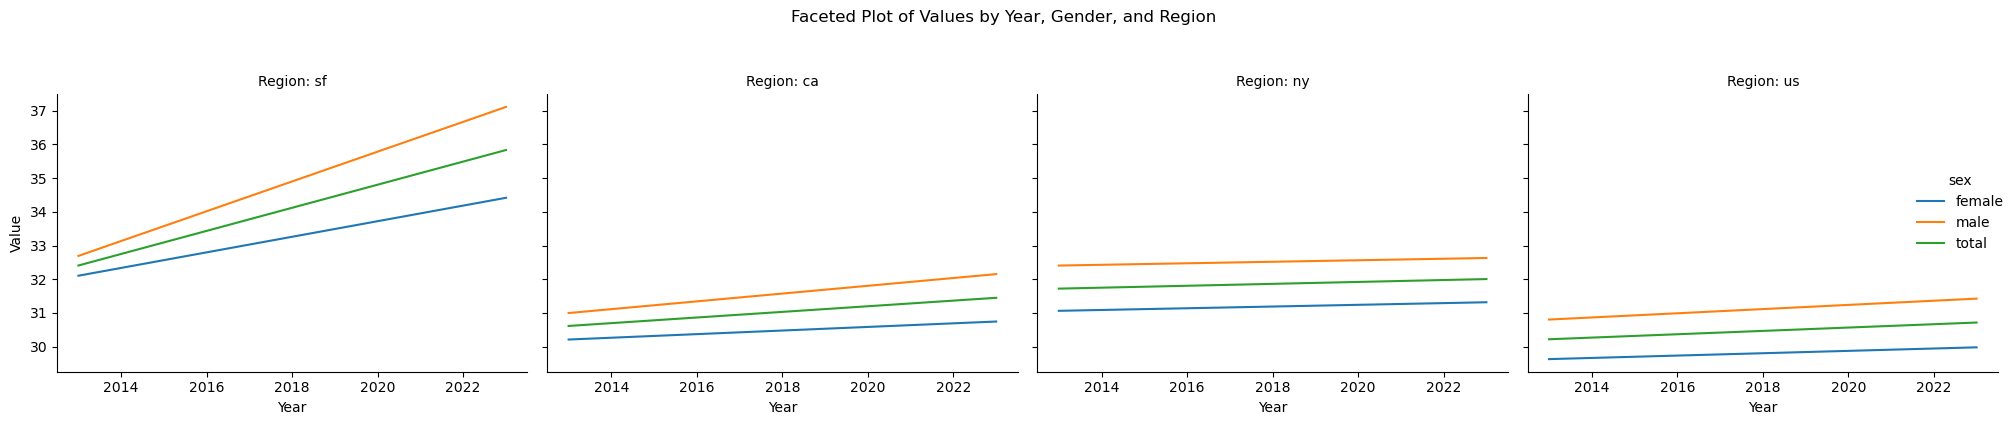

In [55]:
# Create the faceted plot using seaborn.relplot
g = sns.relplot(
    data=df_filtered,
    x='year',
    y='value',
    col='region',
    hue='sex',
    kind='line',
    height=4,
    aspect=1.2,
    facet_kws={'sharey': True} # Share the same y-axis to compare across regions
)

# Set titles and labels
g.set_axis_labels('Year', 'Value')
g.set_titles(col_template='Region: {col_name}')
g.fig.suptitle('Faceted Plot of Values by Year, Gender, and Region', y=1.05)

# Save the plot
plt.tight_layout()

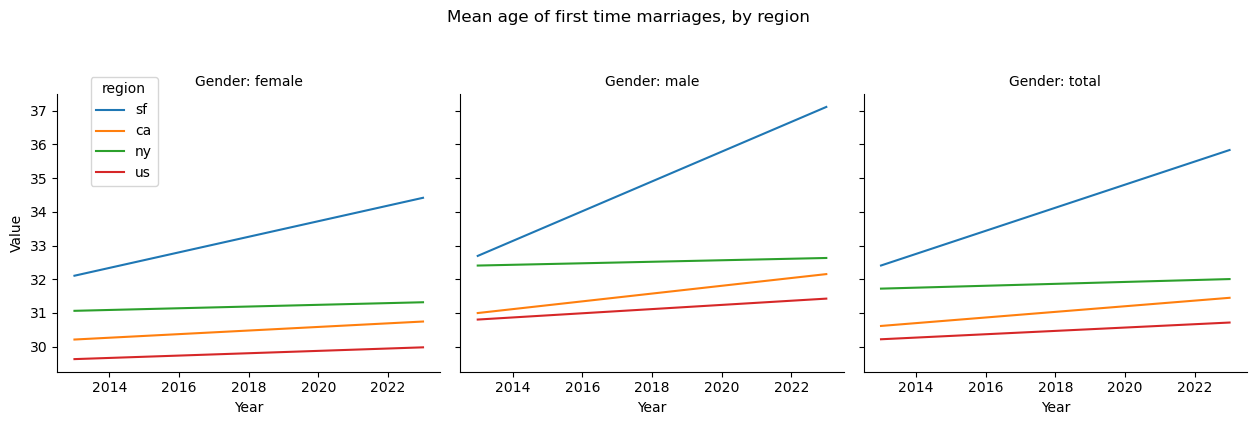

In [56]:
# Create the faceted plot using seaborn.relplot
g = sns.relplot(
    data=df_filtered,
    x='year',
    y='value',
    hue='region',
    col='sex',
    kind='line',
    height=4,
    aspect=1.,
    facet_kws={'sharey': True} # Share the same y-axis to compare across regions
)

# Set titles and labels
g.set_axis_labels('Year', 'Value')
g.set_titles(col_template='Gender: {col_name}')
g.fig.suptitle('Mean age of first time marriages, by region', y=1.05)
# Place the legend below the plot
sns.move_legend(g, "upper left",bbox_to_anchor=(.07,.9),frameon=True)

# Save the plot
plt.tight_layout()

# Marriage rates

In [57]:
def rate_summary_wrapper(df,qry,grp,numerator='f_marriage_1st',denominator='f_unmarried'):

    subset = df.query(qry)
    result = subset.groupby(grp).apply(
    weighted_rate_and_se,
    slug='pct_first_time_married',
    numerator=numerator,
    denominator =denominator,
    scale=1000,
        include_groups=False
)
    return result    

In [58]:
import numpy as np
import pandas as pd

def weighted_rate_and_se(grouped_df, slug='rate', numerator='NUM_VAR', denominator='DENOM_VAR', wgt='PWGTP', scale=100):
    """
    Calculates weighted rates and standard errors for a grouped DataFrame using PUMS replicate weights.
    
    Args:
        grouped_df (pd.DataFrame): The grouped DataFrame.
        slug (str): A string slug for the output rate column.
        numerator (str): The column name for the numerator (e.g., a dummy variable for the event).
        denominator (str): The column name for the denominator (e.g., a dummy variable for the at-risk population).
        wgt (str): The name of the primary weight column.
        scale (int or float): The scaling factor for the rate (e.g., 100 for percentage, 1000 for per-mille rate).
        
    Returns:
        pd.Series: A Series containing the rate, standard error, and other statistics.
    """
    repwgt_str = f'{wgt}\d{{1,2}}'

    
    # Calculate the estimate using primary weights
    prim_num = grouped_df[wgt].mul(grouped_df[numerator]).sum()
    prim_den = grouped_df[wgt].mul(grouped_df[denominator]).sum()
    estim_prim = (prim_num / prim_den) * scale
    
    # Calculate estimates for each replicate weight
    rep_cols = grouped_df.filter(regex=repwgt_str).columns
    estim_reps = {}
    for col in rep_cols:
        rep_num = grouped_df[col].mul(grouped_df[numerator]).sum()
        rep_den = grouped_df[col].mul(grouped_df[denominator]).sum()
        estim_reps[col] = (rep_num / rep_den) * scale
        
    estim_reps = pd.Series(estim_reps)
    
    # Calculate squared differences from the primary estimate
    squared_diffs = (estim_reps - estim_prim)**2
    squared_diffs_summed = squared_diffs.sum()
    
    # Calculate variance and standard error
    variance = (4 / 80.0) * squared_diffs_summed
    standard_error = np.sqrt(variance)
    
    # Calculate other statistics
    moe = standard_error * 1.645
    ci_upper = estim_prim + moe
    ci_lower = estim_prim - moe
    ci_lower = ci_lower if ci_lower > 0 else 0
    
    # Create a Series with the calculated statistics
    output = pd.Series({
        slug: estim_prim,
        numerator: prim_num,
        denominator:prim_den,
        'ci_upper': ci_upper,
        'ci_lower': ci_lower,
        'se': standard_error,
        'moe': moe,
        'sample_recs': grouped_df.shape[0]
    })
    return output

<>:19: SyntaxWarning: invalid escape sequence '\d'
<>:19: SyntaxWarning: invalid escape sequence '\d'
C:\Users\aolsen\AppData\Local\Temp\ipykernel_16112\3781278395.py:19: SyntaxWarning: invalid escape sequence '\d'
  repwgt_str = f'{wgt}\d{{1,2}}'


In [60]:
pd.options.display.float_format = lambda x: f'{x:.1f}'
marriage_rates = pers_ca.query('STATE==6 & county_name=="San Francisco" ').groupby(['year','age_cat']).apply(
    weighted_rate_and_se,
    slug='pct_first_time_married',
    #numerator='f_marriage_1st',
    numerator='f_marriage',
    #denominator ='f_unmarried',
    denominator ='f_fifteen_plus',
    scale=1000,
    include_groups=False
)
marriage_rates

pct_first_time_married  f_marriage  f_fifteen_plus  ci_upper  \
year age_cat                                                                 
2013 16-25                      13.9       613.0         44142.0      21.6   
     26-35                      64.2      6358.0         98980.0      82.7   
     36-45                      18.4      1143.0         61993.0      28.5   
     46-55                       6.5       352.0         54266.0      12.7   
     56-65                       1.4        70.0         49796.0       3.7   
     < 15                        0.0         0.0          3060.0       0.0   
     > 65                        0.0         0.0         70012.0       0.0   
2023 16-25                       5.5       218.0         39826.0      10.6   
     26-35                      64.8      4919.0         75932.0      83.5   
     36-45                      33.6      2032.0         60484.0      48.0   
     46-55                       9.5       458.0         48193.0      18.2   
     56-65                       5.0       229.0         45395.0      11.4   
     < 15                        0.0         0.0          2104.0       0.0   
     > 65                        1.0        76.0         77054.0       2.2   

              ci_lower   se  moe  sample_recs  
year age_cat                                   
2013 16-25         6.1  4.7  7.7        924.0  
     26-35        45.8 11.2 18.5       1528.0  
     36-45         8.4  6.1 10.1       1139.0  
     46-55         0.2  3.8  6.3       1058.0  
     56-65         0.0  1.4  2.3       1016.0  
     < 15          0.0  0.0  0.0        889.0  
     > 65          0.0  0.0  0.0       1310.0  
2023 16-25         0.3  3.1  5.2        925.0  
     26-35        46.1 11.4 18.7       1700.0  
     36-45        19.2  8.8 14.4       1210.0  
     46-55         0.8  5.3  8.7       1066.0  
     56-65         0.0  3.9  6.4       1030.0  
     < 15          0.0  0.0  0.0        834.0  
     > 65          0.0  0.7  1.2       1720.0

In [61]:
slug='married_rate'
    
denom_var='f_fifteen_plus'
#denom_var = 'is_total_pop'
numer_var='f_marriage'
grp = ['year','age_cat']
run_dict = {'sf':{'qry': 'county_name=="San Francisco" ','grp':grp,'numerator':numer_var,'denominator':denom_var},
            'ca':{'qry': ' STATE==6 ','grp':grp,'numerator':numer_var,'denominator':denom_var},
            'nv':{'qry': ' STATE==32 ','grp':grp,'numerator':numer_var,'denominator':denom_var},
            'ut':{'qry': ' STATE==49 ','grp':grp,'numerator':numer_var,'denominator':denom_var},
            'ny':{'qry': ' STATE==36','grp':grp,'numerator':numer_var,'denominator':denom_var},
            'us':{'qry': 'STATE<99 ','grp':grp,'numerator':numer_var,'denominator':denom_var}
}

In [62]:
output ={}
for denom in ['f_fifteen_plus','f_unmarried','is_total_pop']:
    for numer in ['f_marriage','f_marriage_1st']:

        for geo, params in run_dict.items():
            params['denominator'] = denom
            print(geo)
            output[(geo,denom,numer)]=rate_summary_wrapper(pers_ca, **params)

sf
ca
nv
ut
ny
us
sf
ca
nv
ut
ny
us
sf
ca
nv
ut
ny
us
sf
ca
nv
ut
ny
us
sf
ca
nv
ut
ny
us
sf
ca
nv
ut
ny
us


In [63]:
rate_married = pd.concat(output,names=['geo','denominator','numerator'])#.unstack(0).pct_first_time_married
rate_married.pct_first_time_married.unstack(1)

denominator                      f_fifteen_plus  f_unmarried  is_total_pop
geo numerator      year age_cat                                           
ca  f_marriage     2013 16-25              23.2         25.3          11.2
                        26-35              42.0         83.8          20.3
                        36-45              15.5         68.4           7.7
                        46-55               8.6         60.1           4.3
                        56-65               4.1         37.3           2.1
...                                         ...          ...           ...
ut  f_marriage_1st 2023 36-45              10.4         93.8           5.0
                        46-55               2.5         34.7           1.2
                        56-65               4.2         67.4           2.1
                        < 15               11.5         11.7           0.4
                        > 65                6.8        193.2           3.6

[168 rows x 3 columns]

In [64]:
rate_married.loc[['sf','ca','us'],'f_fifteen_plus','f_marriage',2023,['26-35','36-45']]

pct_first_time_married  \
geo denominator    numerator  year age_cat                           
sf  f_fifteen_plus f_marriage 2023 26-35                      64.8   
                                   36-45                      33.6   
ca  f_fifteen_plus f_marriage 2023 26-35                      47.4   
                                   36-45                      15.3   
us  f_fifteen_plus f_marriage 2023 26-35                      47.2   
                                   36-45                      17.3   

                                            f_marriage  f_fifteen_plus  \
geo denominator    numerator  year age_cat                               
sf  f_fifteen_plus f_marriage 2023 26-35        4919.0         75932.0   
                                   36-45        2032.0         60484.0   
ca  f_fifteen_plus f_marriage 2023 26-35      132362.0       2794371.0   
                                   36-45       40351.0       2643858.0   
us  f_fifteen_plus f_marriage 2023 26-35     1066842.0      22605182.0   
                                   36-45      381640.0      22090227.0   

                                            ci_upper  ci_lower   se  moe  \
geo denominator    numerator  year age_cat                                 
sf  f_fifteen_plus f_marriage 2023 26-35        83.5      46.1 11.4 18.7   
                                   36-45        48.0      19.2  8.8 14.4   
ca  f_fifteen_plus f_marriage 2023 26-35        49.8      45.0  1.5  2.4   
                                   36-45        16.5      14.0  0.8  1.3   
us  f_fifteen_plus f_marriage 2023 26-35        48.3      46.1  0.7  1.1   
                                   36-45        17.9      16.7  0.4  0.6   

                                            sample_recs  f_unmarried  \
geo denominator    numerator  year age_cat                             
sf  f_fifteen_plus f_marriage 2023 26-35         1700.0          NaN   
                                   36-45         1210.0          NaN   
ca  f_fifteen_plus f_marriage 2023 26-35        52849.0          NaN   
                                   36-45        50387.0          NaN   
us  f_fifteen_plus f_marriage 2023 26-35       407213.0          NaN   
                                   36-45       409313.0          NaN   

                                            is_total_pop  
geo denominator    numerator  year age_cat                
sf  f_fifteen_plus f_marriage 2023 26-35             NaN  
                                   36-45             NaN  
ca  f_fifteen_plus f_marriage 2023 26-35             NaN  
                                   36-45             NaN  
us  f_fifteen_plus f_marriage 2023 26-35             NaN  
                                   36-45             NaN

In [65]:
pers_ca.groupby(['year','f_unmarried']).PWGTP.sum()

year  f_unmarried
2013  False          285300542
      True            41866897
2023  False          290575476
      True            44339420
Name: PWGTP, dtype: int64

In [66]:
pers_ca.groupby(['year','f_marriage_1st']).PWGTP.sum()

year  f_marriage_1st
2013  False             325478225
      True                1689214
2023  False             333076481
      True                1838415
Name: PWGTP, dtype: int64

In [67]:
pers_ca.groupby(['year','f_marriage']).PWGTP.sum()

year  f_marriage
2013  False         324892578
      True            2274861
2023  False         332543977
      True            2370919
Name: PWGTP, dtype: int64

In [68]:
pers_ca.groupby(['year','f_marriage']).PWGTP.sum()

year  f_marriage
2013  False         324892578
      True            2274861
2023  False         332543977
      True            2370919
Name: PWGTP, dtype: int64